In [18]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import statsmodels.api as sm

In [ ]:
# Load dataset
df = pd.read_csv(r'..\..\data\bitcoin\btcusd_1-min_data.csv')

In [17]:
# Which date has the highest closing price?
highest_close_date = df.loc[df['Close'].idxmax(), 'Timestamp']
highest_close_date = pd.to_datetime(highest_close_date, unit='s').date()
print(f"The date with the highest closing price is: {highest_close_date}")

The date with the highest closing price is: 2025-07-14


In [4]:
# Convert 'Timestamp' to datetime and set as index
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df.set_index('Timestamp', inplace=True)
df = df.sort_index()
df.tail() 

,Open,High,Low,Close,Volume
Timestamp,,,,,
2025-08-02 21:50:00,112955.0,112955.0,112943.0,112944.0,0.369770
2025-08-02 21:51:00,112944.0,112944.0,112943.0,112944.0,0.009608
2025-08-02 21:52:00,112944.0,112956.0,112905.0,112917.0,1.211315
2025-08-02 21:53:00,112917.0,112971.0,112917.0,112971.0,0.366485
2025-08-02 21:54:00,112971.0,113025.0,112970.0,113025.0,2.309270


In [5]:
# Resampling to daily, monthly, yearly, and querterly frequency
df_daily = df.resample('D').mean()
df_monthly = df.resample('ME').mean()
df_yearly = df.resample('YE-DEC').mean() # Resampling the year to December end
df_quarterly = df.resample('QE-DEC').mean() # Resampling to quarterly frequency with December as the end of the quarter

Average Price / Typical Price: It smooths the volatility and better represents the market behavior.

In [6]:
# Compute the Average price
df['Average_Price'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

In [7]:
# Compute VWAP and Resample
VWP = df['Volume'] * df['Average_Price']
# Resample VWAP to daily, monthly, yearly, and quarterly frequency
vwap_minutely = VWP.resample('min').sum() / df['Volume'].resample('min').sum()
vwap_daily = VWP.resample('D').sum()/ df['Volume'].resample('D').sum()
vwap_monthly = VWP.resample('ME').sum()/ df['Volume'].resample('ME').sum()
vwap_yearly = VWP.resample('YE-DEC').sum()/ df['Volume'].resample('YE-DEC').sum()
vwap_quarterly = VWP.resample('QE-DEC').sum()/ df['Volume'].resample('QE-DEC').sum()

df_minute = vwap_minutely.to_frame(name='Weighted_Price')
df_daily = vwap_daily.to_frame(name='Weighted_Price')
df_monthly = vwap_monthly.to_frame(name='Weighted_Price')
df_yearly = vwap_yearly.to_frame(name='Weighted_Price')
df_quarterly = vwap_quarterly.to_frame(name='Weighted_Price')

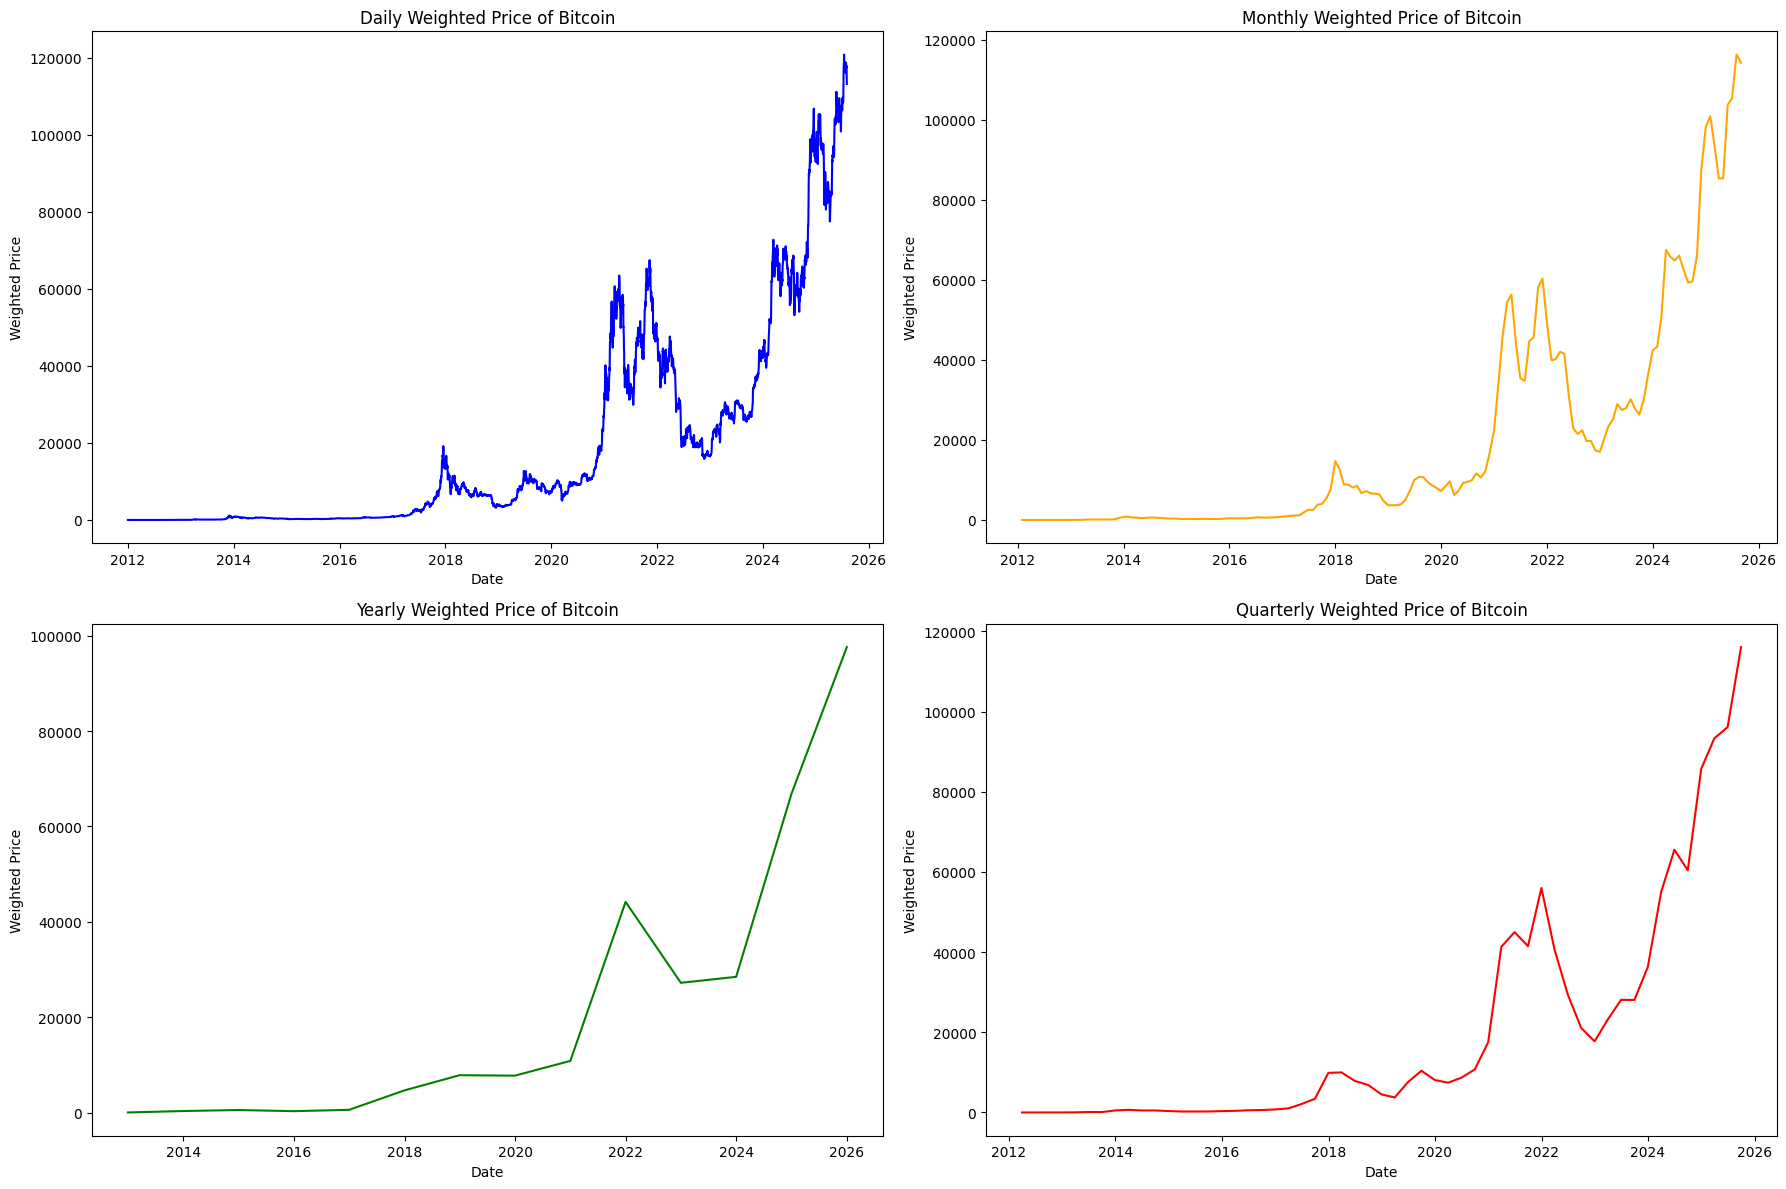

In [8]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# Daily
axs[0, 0].plot(df_daily.index, df_daily['Weighted_Price'], color='blue')
axs[0, 0].set_title('Daily Weighted Price of Bitcoin')
axs[0, 0].set_xlabel('Date')
axs[0, 0].set_ylabel('Weighted Price')

# Monthly
axs[0, 1].plot(df_monthly.index, df_monthly['Weighted_Price'], color='orange')
axs[0, 1].set_title('Monthly Weighted Price of Bitcoin')
axs[0, 1].set_xlabel('Date')
axs[0, 1].set_ylabel('Weighted Price')

# Yearly
axs[1, 0].plot(df_yearly.index, df_yearly['Weighted_Price'], color='green')
axs[1, 0].set_title('Yearly Weighted Price of Bitcoin')
axs[1, 0].set_xlabel('Date')
axs[1, 0].set_ylabel('Weighted Price')

# Quarterly
axs[1, 1].plot(df_quarterly.index, df_quarterly['Weighted_Price'], color='red')
axs[1, 1].set_title('Quarterly Weighted Price of Bitcoin')
axs[1, 1].set_xlabel('Date')
axs[1, 1].set_ylabel('Weighted Price')

plt.tight_layout()
plt.show()


Chain data:
Bigwhale analysis from bigquery?
Which one is more democratized?
Sentiment score compute?

Q. How to know seasonal decompose is additive or multiplicative?


In [ ]:
# What is Trend, Seasonality, and Residuals?
# Trend: The long-term movement in the data, indicating the general direction (upward or downward).
# Seasonality: The repeating patterns or cycles in the data, often related to time (e.g., daily, monthly, yearly).
# Residuals: The remaining part of the data after removing the trend and seasonality, which can be considered as noise or random fluctuations.
# How to know seasonal decompose is additive or multiplicative?
# Seasonal decomposition can be either additive or multiplicative.

In [10]:
# Seasonal decomposition of the daily data
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the index is a complete daily range and set freq
series = df_daily['Weighted_Price']
series = series.asfreq('D')

# Fill missing values if any (e.g., with interpolation or forward fill)
series = series.interpolate()

result_add = seasonal_decompose(series, model='additive', period=365)
result_mult = seasonal_decompose(series, model='multiplicative', period=365)

df_daily['Log_Price'] = np.log(df_daily['Weighted_Price'])
series_log = df_daily['Log_Price'].asfreq('D')
series_log = series_log.interpolate()
result_log = seasonal_decompose(series_log, model='additive', period=365)

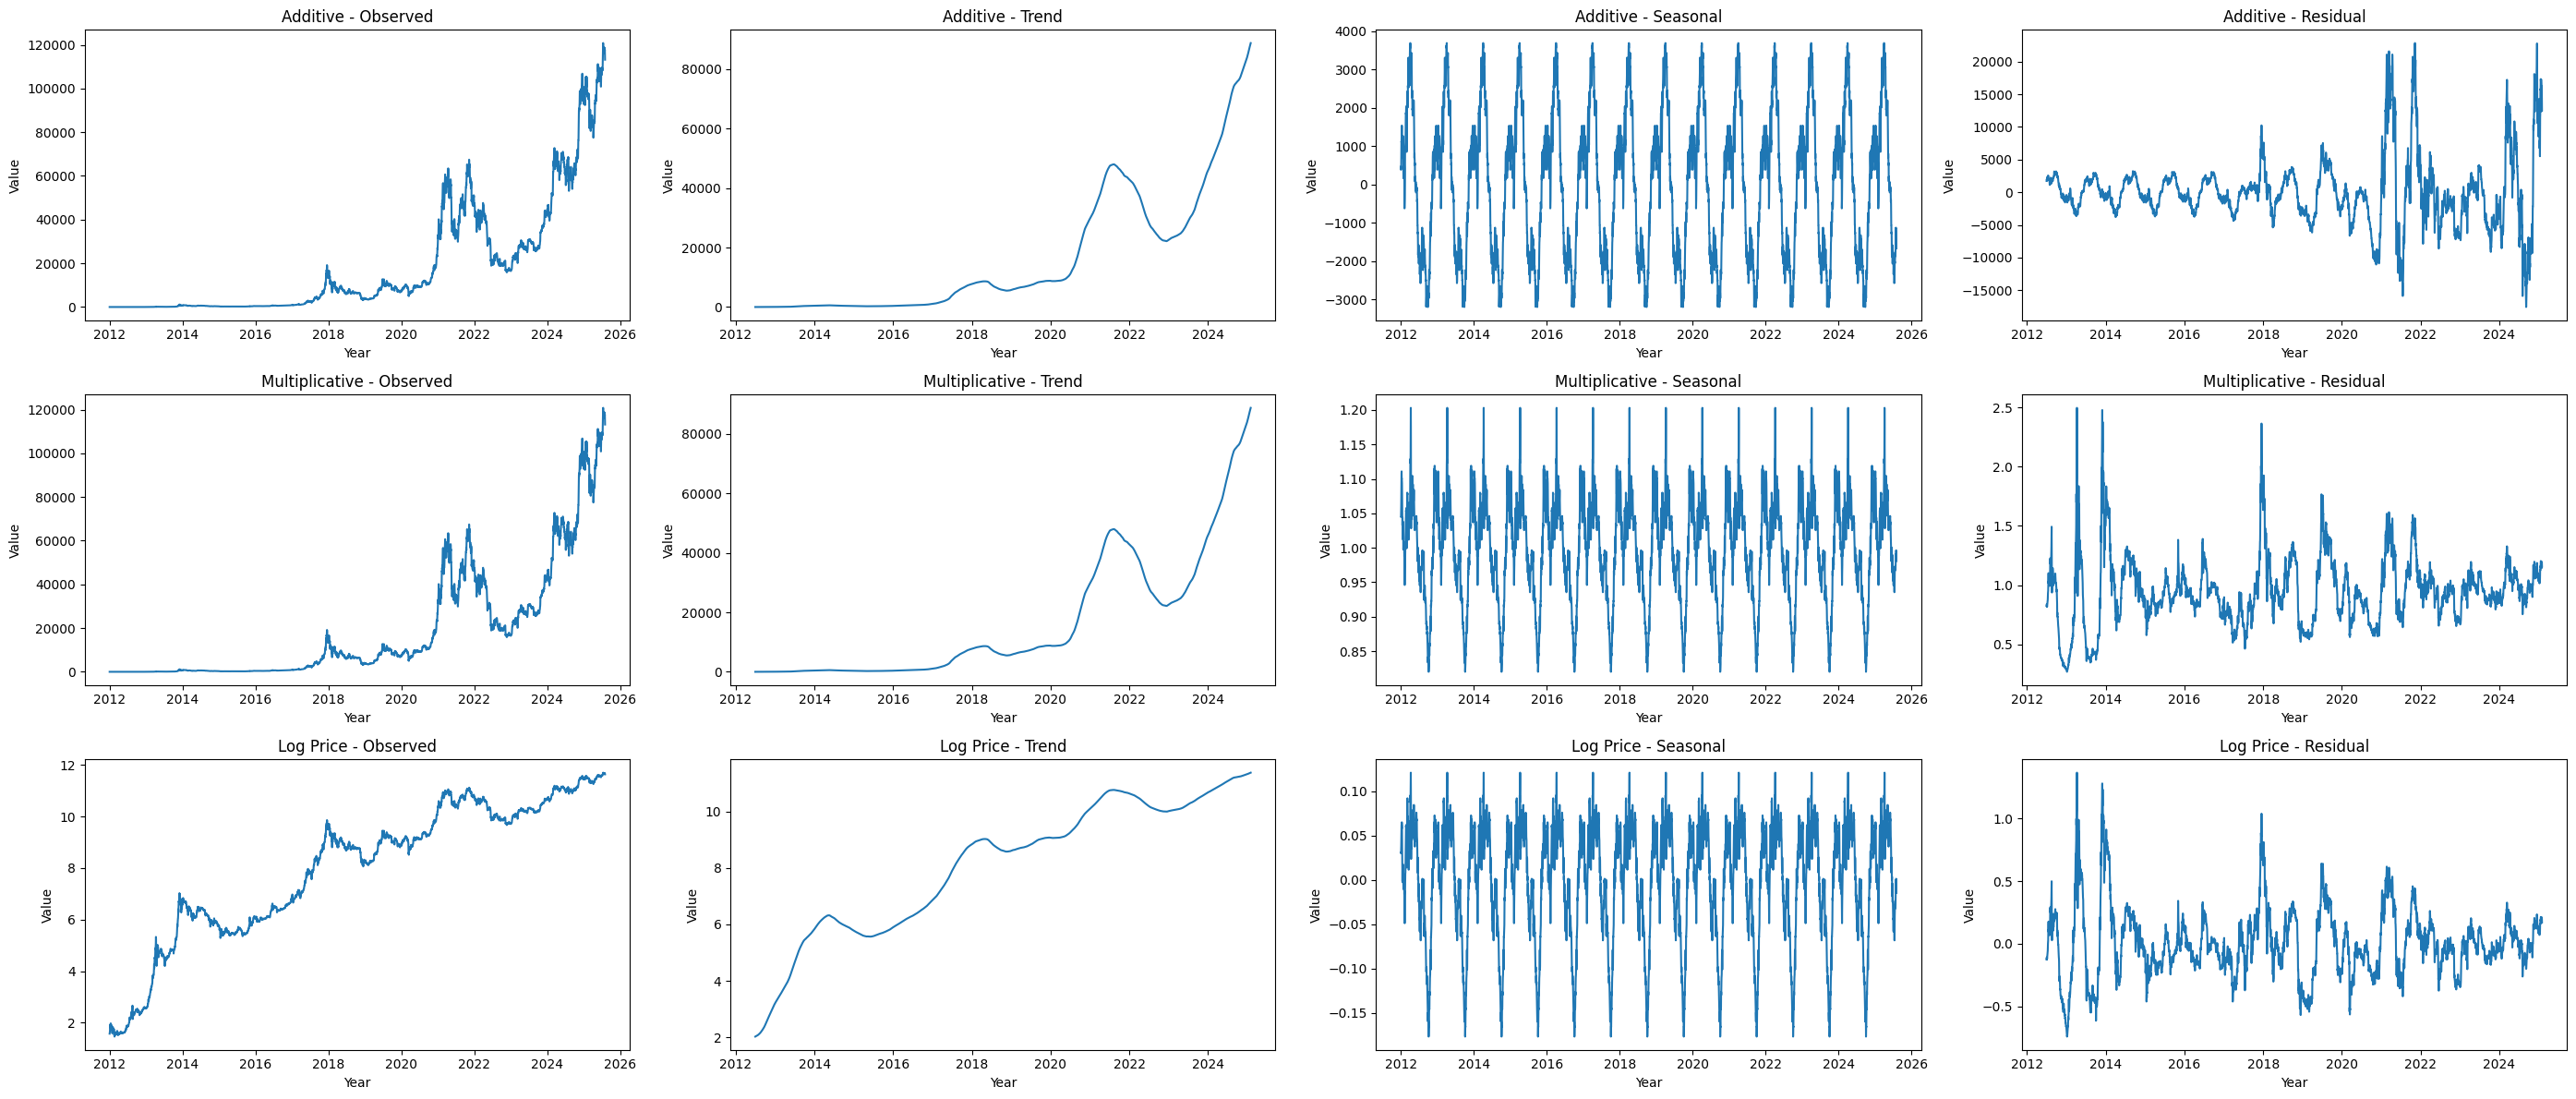

In [11]:
# Top row: Additive, Bottom row: Multiplicative, Third row: Log-Additive

fig, axes = plt.subplots(3, 4, figsize=(28, 12))

# Additive
axes[0, 0].plot(result_add.observed)
axes[0, 0].set_title('Additive - Observed')
axes[0, 1].plot(result_add.trend)
axes[0, 1].set_title('Additive - Trend')
axes[0, 2].plot(result_add.seasonal)
axes[0, 2].set_title('Additive - Seasonal')
axes[0, 3].plot(result_add.resid)
axes[0, 3].set_title('Additive - Residual')

# Multiplicative
axes[1, 0].plot(result_mult.observed)
axes[1, 0].set_title('Multiplicative - Observed')
axes[1, 1].plot(result_mult.trend)
axes[1, 1].set_title('Multiplicative - Trend')
axes[1, 2].plot(result_mult.seasonal)
axes[1, 2].set_title('Multiplicative - Seasonal')
axes[1, 3].plot(result_mult.resid)
axes[1, 3].set_title('Multiplicative - Residual')

# Log-Additive
axes[2, 0].plot(result_log.observed)
axes[2, 0].set_title('Log Price - Observed')
axes[2, 1].plot(result_log.trend)
axes[2, 1].set_title('Log Price - Trend')
axes[2, 2].plot(result_log.seasonal)
axes[2, 2].set_title('Log Price - Seasonal')
axes[2, 3].plot(result_log.resid)
axes[2, 3].set_title('Log Price - Residual')

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()


## Check Missing Value

In [22]:
# Investigate the df_daily['Weighted_Price']
# How many missing values are there?
missing_values = df_daily['Weighted_Price'].isnull().sum()
print(f"Number of missing values in 'Weighted_Price': {missing_values}")
# At what date does the first missing value occur?
first_missing_date = df_daily['Weighted_Price'].isnull().idxmax()
print(f"The first missing value occurs on: {first_missing_date}")

Number of missing values in 'Weighted_Price': 5
The first missing value occurs on: 2012-01-21 00:00:00


In [49]:
# Investigating is there any negative values in the df_daily['Weighted_Price']
negative_values = df_daily['Weighted_Price'][df_daily['Weighted_Price'] < 0]
print(f"Number of negative values in 'Weighted_Price': {len(negative_values)}")

Number of negative values in 'Weighted_Price': 0


## 📉 Stationarity Check

A time series is said to be **stationary** when its statistical properties — such as **mean**, **variance**, and **autocorrelation** — remain constant over time.

To assess stationarity, we use the **Augmented Dickey–Fuller (ADF) test**, which checks for the presence of a unit root:

- **Null Hypothesis (H₀)**: The time series has a unit root → it is *non-stationary*
- **Alternative Hypothesis (H₁)**: The time series does *not* have a unit root → it is *stationary*

> ✅ If the **p-value < 0.05**, we reject the null hypothesis and conclude the series is likely **stationary**.

---

## 🔄 Box-Cox Transformation

The **Box-Cox Transformation** is a method for stabilizing variance and making a time series more normally distributed. This is particularly helpful when your data shows:

- **Non-constant variance** (heteroscedasticity)
- **Skewed distributions**

The transformation is defined as:

\[
y(\lambda) =
\begin{cases}
\frac{y^\lambda - 1}{\lambda}, & \text{if } \lambda \neq 0 \\
\ln(y), & \text{if } \lambda = 0
\end{cases}
\]

Key points:

- `λ` (lambda) is a parameter automatically estimated to best normalize the data.
- Input values must be **strictly positive**.
- Often used prior to differencing in ARIMA models to achieve stationarity.

> 📌 Apply Box-Cox before performing ADF test if variance is not stable over time.


In [75]:
# box-cox transformation
# Box-Cox requires strictly positive values
positive_weighted = df_daily['Weighted_Price'][df_daily['Weighted_Price'] > 0]
df_daily.loc[positive_weighted.index, 'weighted_price_box'], lmbda = stats.boxcox(positive_weighted)
print("Dickey–Fuller test: p=%f" % sm.tsa.stattools.adfuller(df_daily['weighted_price_box'].dropna())[1])
print(f"Lambda for Box-Cox transformation: {lmbda}")

Dickey–Fuller test: p=0.825609
Lambda for Box-Cox transformation: 0.14190196958531515


👉 Since $p \approx 0.83 > 0.05$, we fail to reject the null hypothesis.

In [ ]:
# Compute weekly difference (7-day difference) and drop NaN values
df_daily['weekly_difference'] = df_daily['weighted_price_box'].diff(7).dropna()

# Fill missing values before decomposition
weekly_difference_filled = df_daily['weekly_difference'].interpolate()

Dickey–Fuller test: p=0.000000


In [57]:
# check how many missing values are there weekly_difference_filled
missing_values = weekly_difference_filled.isnull().sum()
print(f"Number of missing values in 'weekly_difference': {missing_values}")

Number of missing values in 'weekly_difference': 7


Dickey-Fuller test statistic: -10.468757697367057
P-value: 1.3008204457141155e-18


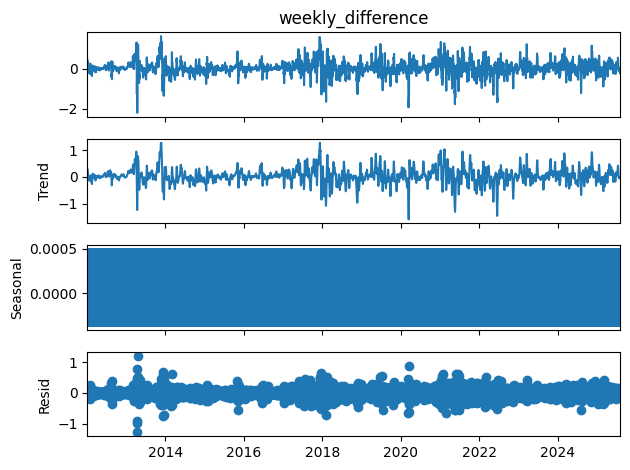

In [71]:
# Seasonal decomposition of the weekly-differenced data
result_weekly_diff_add = seasonal_decompose(weekly_difference_filled.dropna(), model='additive', period=7)

# Perform the Dickey-Fuller test (drop NaNs!)
result = sm.tsa.stattools.adfuller(weekly_difference_filled.dropna())
print(f"Dickey-Fuller test statistic: {result[0]}")
print(f"P-value: {result[1]}")
# plot the seasonal decomposition results
result_weekly_diff_add.plot()
plt.show()

In [ ]:
# Monthly data

In [63]:
# box-cox transformation
# Box-Cox requires strictly positive values
positive_weighted = df_monthly['Weighted_Price'][df_monthly['Weighted_Price'] > 0]
df_monthly.loc[positive_weighted.index, 'weighted_price_box'], lmbda = stats.boxcox(positive_weighted)
print("Dickey–Fuller test: p=%f" % sm.tsa.stattools.adfuller(df_monthly['weighted_price_box'].dropna())[1])
print(f"Lambda for Box-Cox transformation: {lmbda}")

Dickey–Fuller test: p=0.717932
Lambda for Box-Cox transformation: 0.1412278328233731


In [64]:
# Seasonal differentiation
df_monthly['seasonal_prices_box_diff'] = df_monthly.weighted_price_box.diff(12)
print("Dickey–Fuller test: p=%f" % sm.tsa.stattools.adfuller(df_monthly.seasonal_prices_box_diff[12:])[1])

Dickey–Fuller test: p=0.028141


In [65]:
# Regular differentiation
df_monthly['regular_prices_box_diff'] = df_monthly.weighted_price_box.diff(1)
adf_result = sm.tsa.stattools.adfuller(df_monthly['regular_prices_box_diff'].dropna())
print(f"Dickey–Fuller test: p={adf_result[1]:.6f}")

Dickey–Fuller test: p=0.000000


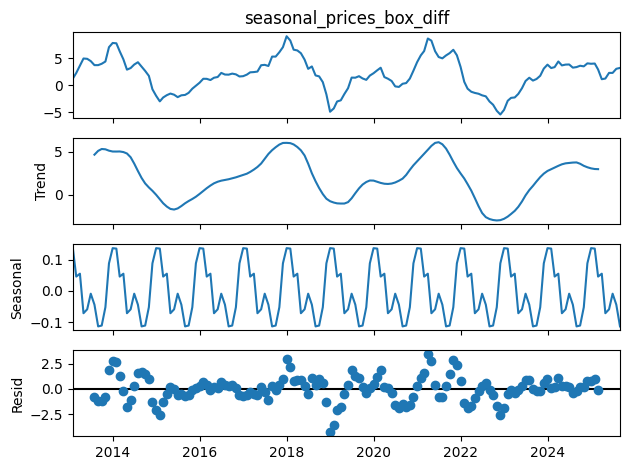

In [67]:
# seasonal decomposition of df_monthly['seasonal_prices_box_diff']
result_seasonal_diff_add = seasonal_decompose(df_monthly['seasonal_prices_box_diff'].dropna(), model='additive', period=12)
# Plot the seasonal decomposition results
result_seasonal_diff_add.plot()
plt.show()

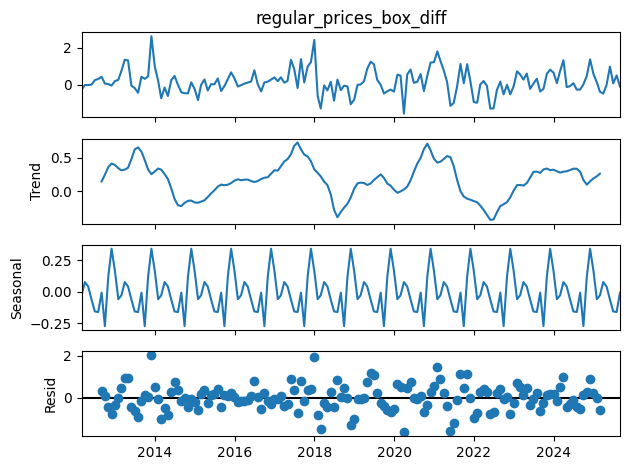

In [68]:
# seasonal decomposition of df_monthly['monthly_prices_box_diff']
result_regular_diff_add = seasonal_decompose(df_monthly['regular_prices_box_diff'].dropna(), model='additive', period=12)
# Plot the seasonal decomposition results
result_regular_diff_add.plot()
plt.show()